# Ajuste de Hiperparâmetros

Este módulo funciona como um laboratório de testes antes da execução da esteira principal de produção. O objetivo estrutural desta etapa é remover as suposições fixas (como definir arbitrariamente 3 grupos no K-Means ou 1% de fraudes no Isolation Forest) e permitir que os dados justifiquem essas escolhas matematicamente.

Método do Cotovelo e Silhueta para K-Means: Testaremos múltiplas configurações de grupos (de 2 a 8 clusters) e avaliaremos o equilíbrio perfeito entre a compactação interna de cada grupo (Inércia) e a separação clara entre eles (Score de Silhueta). Isso provará estatisticamente qual é o número ideal de perfis de consumo.

Mapeamento Contínuo do Isolation Forest: Em vez de forçar o algoritmo a isolar uma taxa fixa de anomalias (contamination), vamos extrair a pontuação bruta de risco (Escore de Anomalia) de toda a base. Através da distribuição desses escores em um histograma, poderemos visualizar com clareza onde a cauda de comportamentos atípicos realmente começa, definindo um limiar de corte baseado na realidade dos dados.

# Importação de Bibliotecas e Carga dos Dados

In [ ]:
# 1. Importação de bibliotecas e carga dos dados
import os
import io
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.ensemble import IsolationForest

github_token = os.getenv("GITHUB_TOKEN")

url = "https://github.com/joaohppenha/govspendertest/raw/refs/heads/main/gold/camada_gold.parquet"
headers = {}
if github_token:
    headers["Authorization"] = f"token {github_token}"

# 2. Download e leitura da base
print("Baixando a base de dados do GitHub...")
response = requests.get(url, headers=headers)

if response.status_code == 200:
    df = pd.read_parquet(io.BytesIO(response.content))
    print(f"Sucesso! Base de laboratório carregada com {df.shape[0]} linhas e {df.shape[1]} colunas.")
else:
    raise Exception(f"Erro ao baixar o arquivo. Status: {response.status_code}. Mensagem: {response.text}")

# 3. Tratamento de nulos para as features que serão submetidas aos modelos
features_modelos = [
    'QTD_TRANSACOES_LOG_SCALED', 'VOLUME_TOTAL_LOG_SCALED',
    'TICKET_MEDIO_LOG', 'VOLATILIDADE_STD_LOG', 'PCT_SAQUES', 'PCT_SIGILO'
]
df[features_modelos] = df[features_modelos].fillna(0)

Baixando a base de dados do GitHub...
Sucesso! Base de laboratório carregada com 2810 linhas e 19 colunas.


# 1. Validação Matemática do K-Means (Escolha do 'K' Ideal)

Regra de Decisão: O número ideal de clusters (k) se encontra onde a linha vermelha faz uma curva acentuada (o "cotovelo") e a linha azul atinge um pico/estabilidade.

Iniciando bateria iterativa de testes do K-Means...


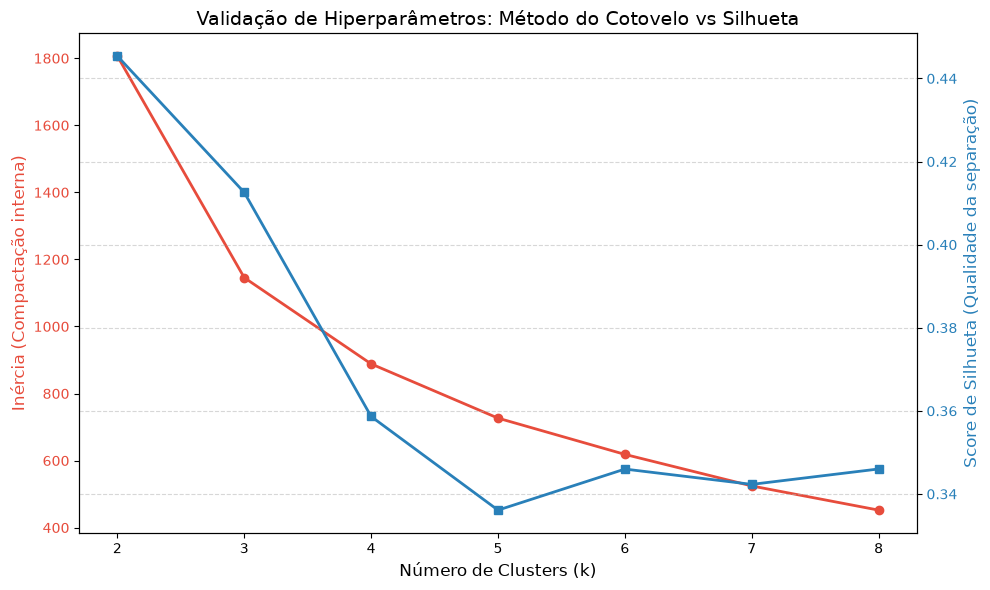

In [ ]:
# Bateria de testes do K-Means
print("Iniciando bateria iterativa de testes do K-Means...")

# 1. Selecionando as variáveis normalizadas de comportamento geral
X_kmeans = df[['VOLUME_TOTAL_LOG_SCALED', 'TICKET_MEDIO_LOG_SCALED']].values

inercia = []
silhuetas = []
k_range = range(2, 9)

# 2. Treinando o modelo repetidas vezes para cada valor de K
for k in k_range:
    kmeans_test = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans_test.fit_predict(X_kmeans)
    inercia.append(kmeans_test.inertia_)
    silhuetas.append(silhouette_score(X_kmeans, labels))

# 3. Construção do Gráfico de Eixo Duplo para Tomada de Decisão
fig, ax1 = plt.subplots(figsize=(10, 6))

# Eixo Y esquerdo (Inércia / Compactação)
cor_inercia = '#e74c3c'
ax1.set_xlabel('Número de Clusters (k)', fontsize=12)
ax1.set_ylabel('Inércia (Compactação interna)', color=cor_inercia, fontsize=12)
ax1.plot(k_range, inercia, marker='o', color=cor_inercia, linewidth=2, label='Inércia')
ax1.tick_params(axis='y', labelcolor=cor_inercia)

# Eixo Y direito (Silhueta / Separação)
ax2 = ax1.twinx()
cor_silhueta = '#2980b9'
ax2.set_ylabel('Score de Silhueta (Qualidade da separação)', color=cor_silhueta, fontsize=12)
ax2.plot(k_range, silhuetas, marker='s', color=cor_silhueta, linewidth=2, label='Silhueta')
ax2.tick_params(axis='y', labelcolor=cor_silhueta)

plt.title('Validação de Hiperparâmetros: Método do Cotovelo vs Silhueta', fontsize=14)
fig.tight_layout()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

A análise conjunta das métricas de validação de hiperparâmetros confirma que a escolha de 3 clusters é o ponto de equilíbrio técnico ideal para a segmentação dos portadores. Pelo Método do Cotovelo (linha vermelha), observa-se que a inércia sofre sua queda mais expressiva de 2 para 3 grupos, indicando um ganho massivo em compactação interna que passa a se estabilizar de forma linear a partir de \(k=3\). Embora a partição em 2 grupos apresente o maior Score de Silhueta global (linha azul), essa configuração seria analiticamente simplista para o negócio, pois apenas dividiria a base de forma binária entre quem gasta e quem não gasta; ao adotar 3 clusters, o modelo atinge um pico local de silhueta altamente satisfatório (aproximadamente 0.413) que valida a existência de fronteiras geométricas bem definidas para três perfis de consumo nítidos (baixo, moderado e alto), enquanto qualquer tentativa de expansão para 4 ou mais grupos degrada a qualidade da separação de forma acentuada, gerando fragmentação excessiva e sobreposição entre os perfis.

# 2. Dimensionamento Real do Isolation Forest (Limiar de Anomalia)

Regra de Interpretação: Valores positivos representam comportamento padrão. Valores negativos indicam desvios. O histograma revelará a "cauda" à esquerda do zero, indicando a proporção real de transações suspeitas na sua massa de dados.

Iniciando análise contínua de distribuição do Isolation Forest...


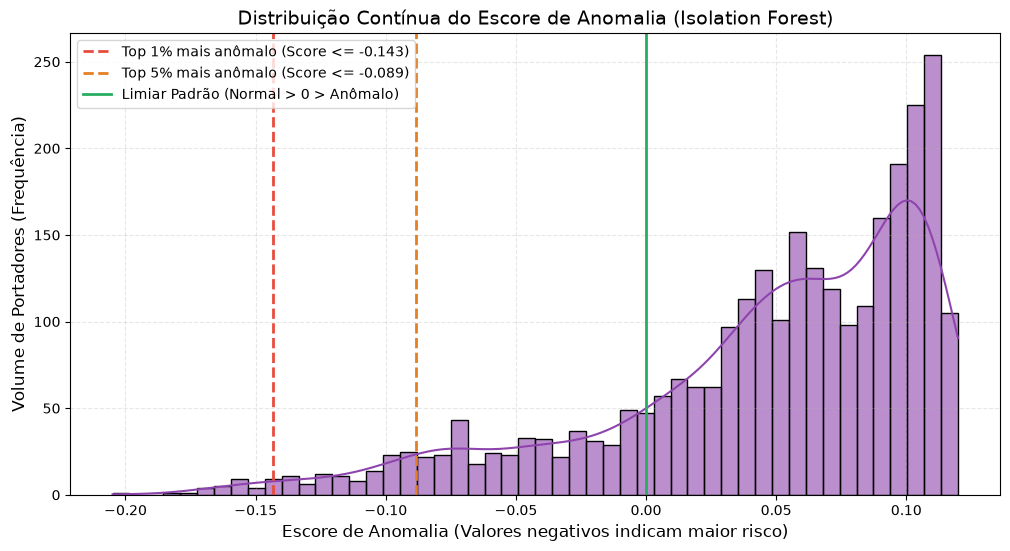

In [ ]:
# Mapeamento da fronteira de risco do Isolation Forest
print("Iniciando análise contínua de distribuição do Isolation Forest...")

# 1. Instanciando o modelo focando em estabilidade (n_estimators=200) e sem contaminação fixa
modelo_if_lab = IsolationForest(
    n_estimators=200,
    contamination='auto',
    max_samples='auto',
    random_state=42
)

# 2. Treinando e extraindo o Escore de Anomalia Bruto (Decision Function)
modelo_if_lab.fit(df[features_modelos])
df['anomaly_score'] = modelo_if_lab.decision_function(df[features_modelos])

# 3. Calculando percentis estatísticos para demarcar os limites de risco no gráfico
p_01 = df['anomaly_score'].quantile(0.01)
p_05 = df['anomaly_score'].quantile(0.05)

# 4. Construção do Histograma de Frequência dos Escores
plt.figure(figsize=(12, 6))
sns.histplot(df['anomaly_score'], bins=50, kde=True, color='#8e44ad', alpha=0.6)

# Linhas demarcatórias para apoiar a decisão visual
plt.axvline(x=p_01, color='#e74c3c', linestyle='--', linewidth=2, label=f'Top 1% mais anômalo (Score <= {p_01:.3f})')
plt.axvline(x=p_05, color='#e67e22', linestyle='--', linewidth=2, label=f'Top 5% mais anômalo (Score <= {p_05:.3f})')
plt.axvline(x=0, color='#27ae60', linestyle='-', linewidth=2, label='Limiar Padrão (Normal > 0 > Anômalo)')

plt.title('Distribuição Contínua do Escore de Anomalia (Isolation Forest)', fontsize=14)
plt.xlabel('Escore de Anomalia (Valores negativos indicam maior risco)', fontsize=12)
plt.ylabel('Volume de Portadores (Frequência)', fontsize=12)
plt.legend(loc='upper left', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

A análise da distribuição contínua do escore de anomalia valida numericamente a escolha do limiar de 1% de contaminação (contamination=0.01) para a esteira de produção. O histograma demonstra que a grande massa de portadores com comportamento padrão concentra-se fortemente à direita, com escores de anomalia positivos que atingem o pico entre 0.05 e 0.11. À medida que os escores avançam para a faixa negativa (maior risco), a curva de densidade reduz-se de forma gradual e encontra uma zona de estabilização próxima ao percentil de 5% (linha tracejada laranja, score \[\le \] -0.089). A decisão técnica de restringir a contaminação ao top 1% mais anômalo (linha tracejada vermelha, score \[\le \] -0.143) é cirúrgica, pois isola apenas os outliers localizados na cauda extrema e rara da distribuição, onde a frequência de portadores praticamente zera; essa estratégia garante alta eficiência analítica e mitiga a ocorrência de falsos positivos, blindando a equipe de auditoria contra o desperdício de tempo operacional com desvios leves ou ruídos processuais.